# Deep Learning

In [1]:
import numpy
numpy.__version__


'1.26.0'

In [2]:
#!pip install numpy==1.26

In [3]:
import torch

In [4]:
device = torch.device("cpu")
print(device)

cpu


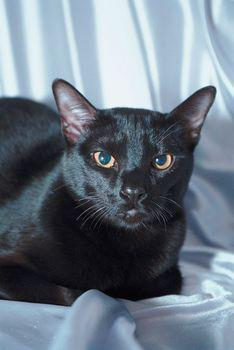

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
image = Image.open("archive/train/cat/Bombay_127_jpg.rf.4c9fde3d1b3fc52a20cd4b2b82b98856.jpg")
image

In [6]:
from torchvision.models import resnet50
modelo = resnet50(weights="IMAGENET1K_V1")
modelo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import SGD

In [8]:
train_folder = ImageFolder("archive/train/")
val_folder = ImageFolder("archive/val/")
train_loader = DataLoader(train_folder, batch_size=32, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=32, shuffle=False)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x1325da960>,
 <torch.utils.data.dataloader.DataLoader at 0x1357d7fb0>)

In [9]:
transform = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop((224)),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ])

In [10]:
train_folder = ImageFolder("archive/train/", transform=transform)
val_folder = ImageFolder("archive/val/", transform=transform)
train_loader = DataLoader(train_folder, batch_size=32, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=32, shuffle=False)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x1357b63c0>,
 <torch.utils.data.dataloader.DataLoader at 0x1357d7f50>)

In [11]:
#congelar capas
for params in modelo.parameters():
    params.requires_grad_ = False
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
modelo.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
modelo.fc = torch.nn.Linear(2048, 2)
modelo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Training Loop

In [16]:
epochs = 3
optimizer = SGD(modelo.parameters(), lr=0.001)
loss_fn = CrossEntropyLoss()
for epoch in range(epochs):
    print(f"Epoch {epoch+i} of {epochs}")
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = modelo(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Loss: {total_loss/len(train_loader)}")



Epoch 1 of 3
Loss: 0.06585508916113111
Epoch 2 of 3
Loss: 0.06260864891939694
Epoch 3 of 3
Loss: 0.059962967617644206


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.6051416].


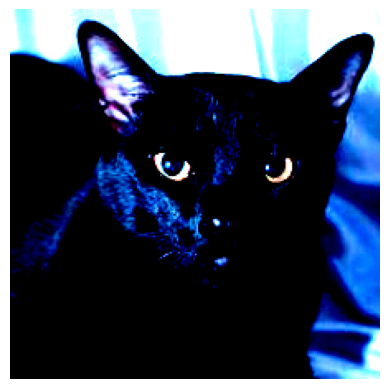

In [24]:
image_t = transform(image)
plt.imshow(image_t.permute(1,2,0))
plt.axis('off')
plt.show()

In [40]:
import pandas as pd
batch = image_t.unsqueeze(0).to(device)
logits = modelo(batch)
probs = torch.nn.functional.softmax(logits, dim=1)
pd.DataFrame(probs.cpu().detach().numpy(), columns=['cat', 'dog'])

,cat,dog
0,0.24149,0.75851
